In [1]:
import json

import matplotlib.pyplot as plt

In [2]:
# Read the benchmark results from the JSON file
with open("benchmark.json", "r") as f:
    data = json.load(f)
benchmarks = data["benchmarks"]
len(benchmarks)

128

Saved linear_forward_256x256.png


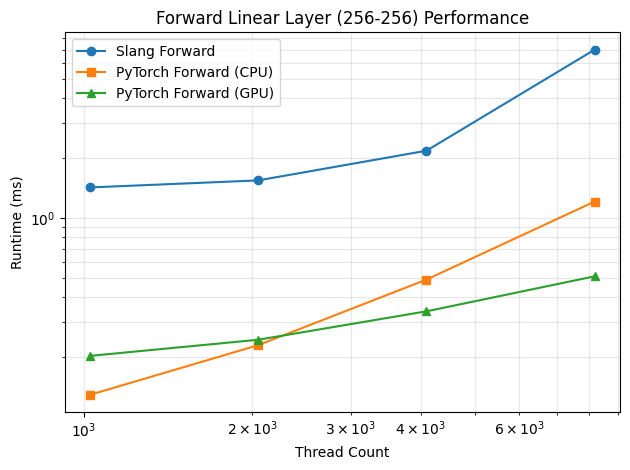

Saved linear_forward_128x128.png


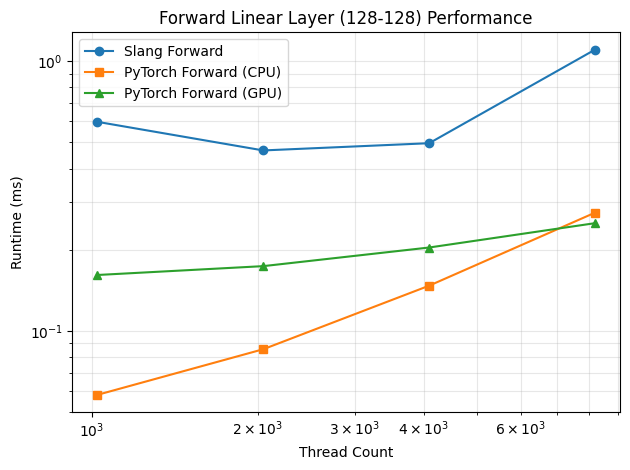

Saved linear_forward_64x64.png


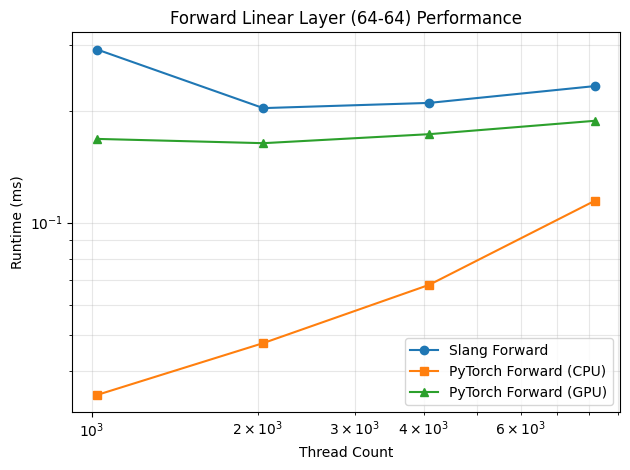

In [3]:
# Create plots for all three configurations and save to PNG files
configurations = ["256-256", "128-128", "64-64"]

for config in configurations:
    slang_data = {}
    torch_cpu_data = {}
    torch_gpu_data = {}
    
    for bench in benchmarks:
        name = bench.get("name", "")
        param = bench.get("param", "")
        
        # Filter for current configuration
        if config not in param:
            continue
        
        # Extract thread count from param (format: "256-256-1024")
        parts = param.split("-")
        if len(parts) != 3:
            continue
        thread_count = int(parts[2])
        
        # Get mean runtime in milliseconds
        stats = bench.get("stats", {})
        mean_time = stats.get("mean", 0) * 1000  # Convert to milliseconds
        
        if "test_linear_layer_slang[" in name:
            slang_data[thread_count] = mean_time
        elif "test_linear_layer_torch[" in name and "gpu" not in name:
            torch_cpu_data[thread_count] = mean_time
        elif "test_linear_layer_torch_gpu[" in name:
            torch_gpu_data[thread_count] = mean_time
    
    # Sort by thread count
    slang_threads = sorted(slang_data.keys())
    torch_cpu_threads = sorted(torch_cpu_data.keys())
    torch_gpu_threads = sorted(torch_gpu_data.keys())
    
    slang_times = [slang_data[t] for t in slang_threads]
    torch_cpu_times = [torch_cpu_data[t] for t in torch_cpu_threads]
    torch_gpu_times = [torch_gpu_data[t] for t in torch_gpu_threads]
    
    # Create the plot with log scale
    plt.figure()
    plt.loglog(slang_threads, slang_times, 'o-', label="Slang Forward")
    plt.loglog(torch_cpu_threads, torch_cpu_times, 's-', label="PyTorch Forward (CPU)")
    plt.loglog(torch_gpu_threads, torch_gpu_times, '^-', label="PyTorch Forward (GPU)")
    
    plt.xlabel("Thread Count")
    plt.ylabel("Runtime (ms)")
    plt.title(f"Forward Linear Layer ({config}) Performance")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    
    # Save to PNG file
    filename = f"linear_forward_{config.replace('-', 'x')}.png"
    plt.savefig(filename)
    print(f"Saved {filename}")
    plt.show()


Saved linear_backward_256x256.png


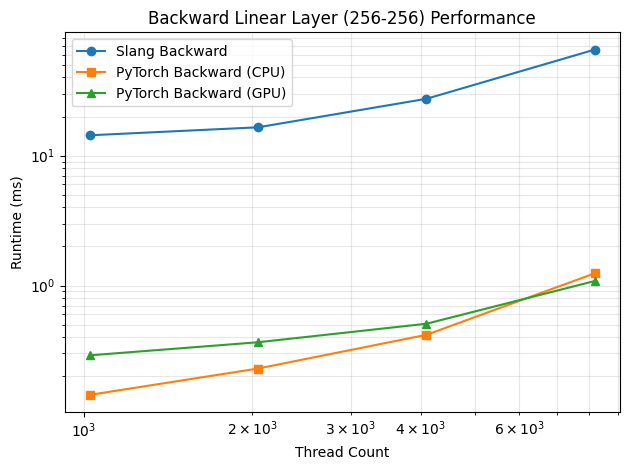

Saved linear_backward_128x128.png


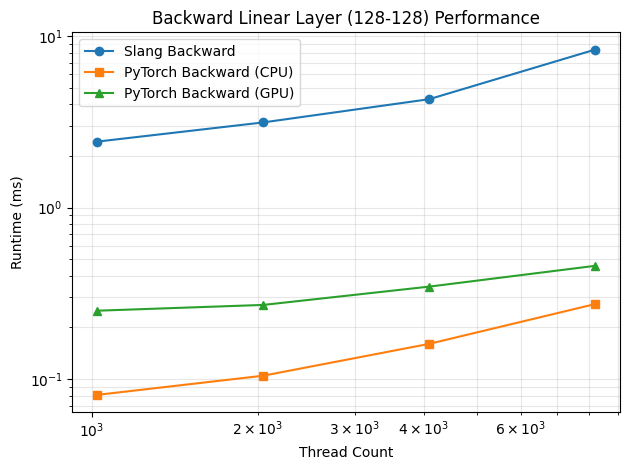

Saved linear_backward_64x64.png


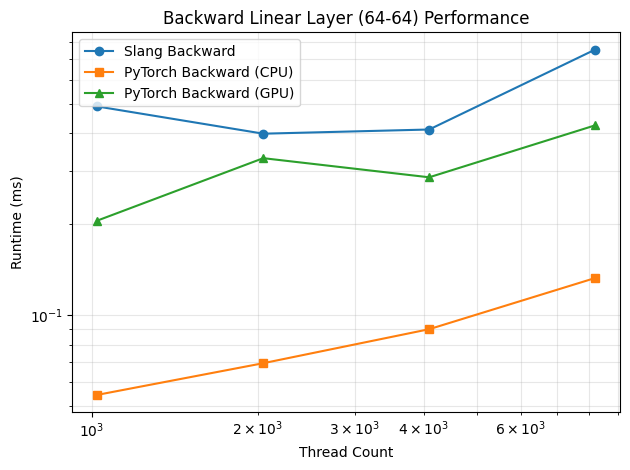

In [4]:
# Create plots for backward pass across all three configurations and save to PNG files
configurations = ["256-256", "128-128", "64-64"]

for config in configurations:
    slang_data = {}
    torch_cpu_data = {}
    torch_gpu_data = {}
    
    for bench in benchmarks:
        name = bench.get("name", "")
        param = bench.get("param", "")
        
        # Filter for current configuration
        if config not in param:
            continue
        
        # Extract thread count from param (format: "256-256-1024")
        parts = param.split("-")
        if len(parts) != 3:
            continue
        thread_count = int(parts[2])
        
        # Get mean runtime in milliseconds
        stats = bench.get("stats", {})
        mean_time = stats.get("mean", 0) * 1000  # Convert to milliseconds
        
        # Filter for backward tests
        if "test_linear_layer_backward_slang[" in name and "atomic" not in name:
            slang_data[thread_count] = mean_time
        elif "test_linear_layer_backward_torch[" in name and "gpu" not in name:
            torch_cpu_data[thread_count] = mean_time
        elif "test_linear_layer_backward_torch_gpu[" in name:
            torch_gpu_data[thread_count] = mean_time
    
    # Sort by thread count
    slang_threads = sorted(slang_data.keys())
    torch_cpu_threads = sorted(torch_cpu_data.keys())
    torch_gpu_threads = sorted(torch_gpu_data.keys())
    
    slang_times = [slang_data[t] for t in slang_threads]
    torch_cpu_times = [torch_cpu_data[t] for t in torch_cpu_threads]
    torch_gpu_times = [torch_gpu_data[t] for t in torch_gpu_threads]
    
    # Create the plot with log scale
    plt.figure()
    plt.loglog(slang_threads, slang_times, 'o-', label="Slang Backward")
    plt.loglog(torch_cpu_threads, torch_cpu_times, 's-', label="PyTorch Backward (CPU)")
    plt.loglog(torch_gpu_threads, torch_gpu_times, '^-', label="PyTorch Backward (GPU)")
    
    plt.xlabel("Thread Count")
    plt.ylabel("Runtime (ms)")
    plt.title(f"Backward Linear Layer ({config}) Performance")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    
    # Save to PNG file
    filename = f"linear_backward_{config.replace('-', 'x')}.png"
    plt.savefig(filename)
    print(f"Saved {filename}")
    plt.show()
